# FLUX Artifact Generation Pipeline

This notebook handles the FLUX generation part of the artifact generation pipeline:
1. Load annotation data generated by the GSAM notebook
2. Initialize FLUX models
3. Generate artifact images using the patch-based guidance

**Prerequisites:** Run the GSAM annotation generation notebook first to create annotation files.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
os.chdir('/home/jhpark/image-artifacts/src')
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [3]:
# Install required packages if needed
# !pip install torch torchvision transformers openai PIL numpy tqdm matplotlib
# !pip install diffusers accelerate

import json
import time
import traceback
from glob import glob

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

from typing import List, Tuple

# Add pipeline to path
from pipeline import ImageVisualizer


from pipeline import FluxGenerator
from pipeline.flux_generator import FluxConfig
from flux.artifacts_util import patch_coor_to_ind
from pipeline.instance_processor import InstanceProcessor
from notebooks.fusion_strategies import strategy_1, strategy_2, strategy_3, strategy_4, strategy_5

/home/jhpark/anaconda3/envs/rf-solver/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# FLUX Generation Configuration
FLUX_CONFIG = {
    # FLUX parameters
    'guidance': 5.0,
    'num_steps': 25,
    'inject_step': 20,
    'pe_step_addition': 25,
    'pe_step_removal': 25,
    'pe_step_distortion': 20,
    'pe_step_fusion': 20,
    'seed': 42,
    'use_rf_solver': False,
    'device': 'cuda:0' if torch.cuda.is_available() else 'cpu',
    
    # Paths
    'annotation_dir': 'notebooks/annotations',
}

# Create FluxConfig object with parameters from FLUX_CONFIG
flux_config = FluxConfig(
    name='flux-dev',  # Default model name
    guidance=FLUX_CONFIG['guidance'],
    num_steps=FLUX_CONFIG['num_steps'],
    inject_step=FLUX_CONFIG['inject_step'],
    pe_step={
        'addition': FLUX_CONFIG['pe_step_addition'],
        'removal': FLUX_CONFIG['pe_step_removal'],
        'distortion': FLUX_CONFIG['pe_step_distortion'],
        'fusion': FLUX_CONFIG['pe_step_fusion']
    },
    seed=FLUX_CONFIG['seed'],
    use_rf_solver=FLUX_CONFIG['use_rf_solver']
)

# Initialize FLUX generator with proper config object
flux_generator = FluxGenerator(
    device=FLUX_CONFIG['device'],
    config=flux_config
)
    
# Initialize visualizer
visualizer = ImageVisualizer()

Loading FLUX models...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Init model
Loading checkpoint
Init AE
FLUX models loaded successfully.


In [5]:
# Functions to load final artifact data (from patch generation)
def list_available_annotations(annotation_dir):
    """List all available final artifact files"""
    final_files = glob(os.path.join(annotation_dir, "*_step3_data.json"))
    if not final_files:
        return []
    
    final_artifacts = []
    for file_path in final_files:
        try:
            base_name = os.path.basename(file_path)
            final_id = base_name.replace("_step3_data.json", "")
            
            # Load basic info
            with open(file_path, 'r') as f:
                data = json.load(f)
            final_artifacts.append({
                'final_id': final_id,
                'file_path': file_path,
                'image_id': data.get('image_info', {}).get('id', 'unknown'),
                'filename': data.get('image_info', {}).get('file_name', 'unknown'),
                'caption': data.get('caption', 'No caption'),
                'step3_data_list': data.get('step3_data_list', []),
                'timestamp': data.get('timestamp', 'unknown'),
                'source_step3_id': data.get('source_step3_id', 'unknown')
            })
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue
    
    return sorted(final_artifacts, key=lambda x: x['timestamp'], reverse=True)

def load_final_artifact_data(exp_data, annotation_dir):
    """Load final artifact data by ID"""
    final_id = exp_data['final_id']
    # Load final artifacts JSON
    final_file = os.path.join(annotation_dir, f"{final_id}_step3_data.json")
    if not os.path.exists(final_file):
        raise FileNotFoundError(f"Final artifacts file not found: {final_file}")
    
    with open(final_file, 'r') as f:
        final_data = json.load(f)
    
    # Load image array
    image_file = os.path.join(annotation_dir, f"{final_id}_image.npy")
    if not os.path.exists(image_file):
        raise FileNotFoundError(f"Image file not found: {image_file}")
    
    img_array = np.load(image_file)
    # Convert list artifacts back to proper format
    def convert_lists_to_numpy(obj):
        if isinstance(obj, dict):
            converted = {}
            for k, v in obj.items():
                if k in ['target_mask', 'reference_mask'] and isinstance(v, list):
                    converted[k] = np.array(v, dtype=bool)
                elif k in ['target_bbox', 'reference_bbox'] and isinstance(v, list):
                    converted[k] = np.array(v, dtype=float)
                else:
                    converted[k] = convert_lists_to_numpy(v)
            return converted
        elif isinstance(obj, list):
            return [convert_lists_to_numpy(item) for item in obj]
        else:
            return obj
    
    step3_data_list = convert_lists_to_numpy(final_data['step3_data_list'])
    
    return {
        'img_array': img_array,
        'step3_data_list': final_data['step3_data_list'],
        'caption': final_data['caption'],
        'image_info': final_data['image_info'],
        'config': final_data.get('patch_config', {}),
        'timestamp': final_data.get('timestamp', 'unknown'),
        'source_step3_id': final_data.get('source_step3_id', 'unknown')
    }

def create_and_save_four_images(original_img, generated_img, target_mask, patch_coords, patch_size, exp_dir, exp_name):
    """
    Create and save 4 different images:
    1. generated_image
    2. original image with target region masked out
    3. original image with target region only
    4. generated_image with target region only
    """
    import numpy as np
    from PIL import Image
    
    # Convert images to numpy arrays for processing
    if isinstance(original_img, Image.Image):
        original_array = np.array(original_img)
    else:
        original_array = original_img
        
    if isinstance(generated_img, Image.Image):
        generated_array = np.array(generated_img)
    else:
        generated_array = generated_img
    
    img_h, img_w = original_array.shape[:2]
    
    # Create a mask for the target region
    mask = np.zeros((img_h, img_w), dtype=bool)
    for row, col in patch_coords:
        y_start = row * patch_size
        x_start = col * patch_size
        y_end = min(y_start + patch_size, img_h)
        x_end = min(x_start + patch_size, img_w)
        mask[y_start:y_end, x_start:x_end] = True
    
    # 1. Save generated image as-is
    if isinstance(generated_img, Image.Image):
        generated_img.save(os.path.join(exp_dir, f"generated.png"))
    else:
        Image.fromarray(generated_array).save(os.path.join(exp_dir, f"generated.png"))
    
    # 2. Original image with target region masked out
    original_masked = original_array.copy()
    if original_masked.dtype == np.uint8:
        fill_value = 0
    else:
        fill_value = 0.0
    original_masked[mask] = fill_value if np.isscalar(fill_value) else np.array(fill_value)
    
    # 3 & 4. Original and generated images with only target region visible (cropped and resized)
    # Find bounding box of the mask
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    
    if not np.any(rows) or not np.any(cols):
        # Empty mask, use original approach
        original_only_target = np.zeros_like(original_array)
        original_only_target[mask] = original_array[mask]
        generated_only_target = np.zeros_like(generated_array)
        generated_only_target[mask] = generated_array[mask]
    else:
        y_min, y_max = np.where(rows)[0][[0, -1]]
        x_min, x_max = np.where(cols)[0][[0, -1]]
        
        # Crop the original and generated images to the bounding box
        original_cropped = original_array[y_min:y_max+1, x_min:x_max+1]
        generated_cropped = generated_array[y_min:y_max+1, x_min:x_max+1]
        
        # Get the longest side of the original image
        orig_h, orig_w = original_array.shape[:2]
        max_orig_side = max(orig_h, orig_w)
        
        # Get dimensions of cropped region
        crop_h, crop_w = original_cropped.shape[:2]
        max_crop_side = max(crop_h, crop_w)
        
        # Calculate resize ratio
        resize_ratio = max_orig_side / max_crop_side
        new_h = int(crop_h * resize_ratio)
        new_w = int(crop_w * resize_ratio)
        
        # Function to convert to PIL for resizing
        def to_pil_for_resize(img):
            arr = img
            if arr.dtype in (np.float32, np.float64):
                if arr.max() <= 1.0:
                    arr = (arr * 255).clip(0, 255)
                arr = arr.astype(np.uint8)
            if arr.ndim == 2:
                return Image.fromarray(arr)
            elif arr.shape[2] == 1:
                return Image.fromarray(arr[:, :, 0])
            elif arr.shape[2] == 3:
                return Image.fromarray(arr)
            elif arr.shape[2] == 4:
                return Image.fromarray(arr[:, :, :3])
            else:
                raise ValueError(f"Unexpected image shape: {arr.shape}")
        
        # Convert to PIL images for resizing
        original_pil = to_pil_for_resize(original_cropped)
        generated_pil = to_pil_for_resize(generated_cropped)
        
        # Resize
        original_resized = original_pil.resize((new_w, new_h), Image.LANCZOS)
        generated_resized = generated_pil.resize((new_w, new_h), Image.LANCZOS)
        
        # Convert back to numpy arrays with original dtype
        original_only_target = np.array(original_resized)
        generated_only_target = np.array(generated_resized)
        
        # Convert back to original data type if needed
        if original_array.dtype in (np.float32, np.float64):
            original_only_target = original_only_target.astype(original_array.dtype) / 255.0
            generated_only_target = generated_only_target.astype(original_array.dtype) / 255.0
    
    # Convert to PIL and save images
    def to_pil(img):
        arr = img
        if arr.dtype in (np.float32, np.float64):
            if arr.max() <= 1.0:
                arr = (arr * 255).clip(0, 255)
            arr = arr.astype(np.uint8)
        if arr.ndim == 2:
            return Image.fromarray(arr)
        elif arr.shape[2] == 1:
            return Image.fromarray(arr[:, :, 0])
        elif arr.shape[2] == 3:
            return Image.fromarray(arr)
        elif arr.shape[2] == 4:
            return Image.fromarray(arr[:, :, :3])
        else:
            raise ValueError(f"Unexpected image shape: {arr.shape}")
    
    # Save all images
    to_pil(original_masked).save(os.path.join(exp_dir, f"original_masked.png"))
    to_pil(original_only_target).save(os.path.join(exp_dir, f"original_target.png"))
    to_pil(generated_only_target).save(os.path.join(exp_dir, f"generated_target.png"))
    
    print(f"Saved 4 images for {exp_name}")

print("Final artifact loading functions defined")
print("Image processing functions defined")

available_final_artifacts = list_available_annotations(FLUX_CONFIG['annotation_dir'])
final_artifacts_iter = iter(available_final_artifacts)


Final artifact loading functions defined
Image processing functions defined


In [ ]:
exp_dir = os.path.join('/data3/jhpark/fusion_exp/', "exp5")
os.makedirs(exp_dir, exist_ok=True)

for i, final_artifact in enumerate(available_final_artifacts):
    loaded_data = load_final_artifact_data(final_artifact, FLUX_CONFIG['annotation_dir'])
    exp_name = loaded_data['image_info']['file_name'][:-4]
    sub_exp_dir = os.path.join(exp_dir, exp_name)
    os.makedirs(sub_exp_dir, exist_ok=True)
    H, W = loaded_data['img_array'].shape[0], loaded_data['img_array'].shape[1]
    patch_size = 16
    patch_H = H
    patch_W = W
    patch_w = patch_W // patch_size
    patch_h = patch_H // patch_size
    target_coords_final, reference_coords_final = strategy_5(loaded_data)
        # Extract data
    img_array = loaded_data['img_array']
    step3_data_list = loaded_data['step3_data_list']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    data = loaded_data['step3_data_list'][0]
    artifact_data = {
        'artifact_type': 'fusion',
        'entity': data['entity_A'],
        'fused_entity': data['entity_B'],
        'reference_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in reference_coords_final],
        'target_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in target_coords_final],
        'target_mask': InstanceProcessor.patches_to_masks(target_coords_final, img_array.shape),
        'reference_mask': InstanceProcessor.patches_to_masks(reference_coords_final, img_array.shape),
    }
    artifacts = [artifact_data]
        # Extract data
    img_array = loaded_data['img_array']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    artifact = artifacts[0]

    generated_image = flux_generator.inject_artifacts(
        source_prompt=caption,
        target_prompt=caption,
        artifact_data=[artifact],
        source_img=Image.fromarray(img_array),
        pe_step=20,
    )

    # Create and save the 4 different images
    create_and_save_four_images(
        original_img=img_array,
        generated_img=generated_image,
        target_mask=artifact['target_mask'],
        patch_coords=target_coords_final,
        patch_size=patch_size,
        exp_dir=sub_exp_dir,
        exp_name=exp_name
    )

Generating with seed 42:
two sheep laying down
Done in 13.9s.
Saved 4 images for 000000114616
Generating with seed 42:
a zebra and a baby zebra standing in a field
Done in 13.9s.
Saved 4 images for 000000358685
Generating with seed 42:
two black and white cats sitting in the grass
Done in 13.3s.
Saved 4 images for 000000074883
Generating with seed 42:
a family of geese standing in a field
Done in 14.4s.
Saved 4 images for 000000531550
Generating with seed 42:
two cows standing in a field
Done in 16.6s.
Saved 4 images for 000000377188
Generating with seed 42:
the giraffe is brown and white
Done in 15.5s.
Saved 4 images for 000000252873
Generating with seed 42:
two zebras eating grass
Done in 15.6s.
Saved 4 images for 000000279165
Generating with seed 42:
a group of zebras standing in a field
Done in 14.9s.
Saved 4 images for 000000376090
Generating with seed 42:
a group of giraffes walking in the wild
Done in 15.8s.
Saved 4 images for 000000326475
Generating with seed 42:
a herd of elep

: 

In [ ]:
exp_dir = os.path.join('/data3/jhpark/fusion_exp/', "exp2")
os.makedirs(exp_dir, exist_ok=True)

for i, final_artifact in enumerate(available_final_artifacts):
    loaded_data = load_final_artifact_data(final_artifact, FLUX_CONFIG['annotation_dir'])
    exp_name = loaded_data['image_info']['file_name'][:-4]
    H, W = loaded_data['img_array'].shape[0], loaded_data['img_array'].shape[1]
    patch_size = 16
    patch_H = H
    patch_W = W
    patch_w = patch_W // patch_size
    patch_h = patch_H // patch_size
    target_coords_final, reference_coords_final = strategy_2(loaded_data)
        # Extract data
    img_array = loaded_data['img_array']
    step3_data_list = loaded_data['step3_data_list']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    data = loaded_data['step3_data_list'][0]
    artifact_data = {
        'artifact_type': 'fusion',
        'entity': data['entity_A'],
        'fused_entity': data['entity_B'],
        'reference_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in reference_coords_final],
        'target_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in target_coords_final],
        'target_mask': InstanceProcessor.patches_to_masks(target_coords_final, img_array.shape),
        'reference_mask': InstanceProcessor.patches_to_masks(reference_coords_final, img_array.shape),
    }
    artifacts = [artifact_data]
        # Extract data
    img_array = loaded_data['img_array']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    artifact = artifacts[0]

    generated_image = flux_generator.inject_artifacts(
        source_prompt=caption,
        target_prompt=caption,
        artifact_data=[artifact],
        source_img=Image.fromarray(img_array),
        pe_step=20,
    )

    # Create and save the 4 different images
    create_and_save_four_images(
        original_img=img_array,
        generated_img=generated_image,
        target_mask=artifact['target_mask'],
        patch_coords=target_coords_final,
        patch_size=patch_size,
        exp_dir=exp_dir,
        exp_name=exp_name
    )

Generating with seed 42:
two sheep laying down
Done in 13.6s.
Generating with seed 42:
a zebra and a baby zebra standing in a field
Done in 14.4s.
Generating with seed 42:
two black and white cats sitting in the grass
Done in 13.6s.
Generating with seed 42:
a family of geese standing in a field
Done in 14.5s.
Generating with seed 42:
two cows standing in a field
Done in 16.4s.
Generating with seed 42:
the giraffe is brown and white
Done in 15.2s.
Generating with seed 42:
two zebras eating grass
Done in 15.2s.
Generating with seed 42:
a group of zebras standing in a field
Done in 14.4s.
Generating with seed 42:
a group of giraffes walking in the wild
Done in 15.2s.
Generating with seed 42:
a herd of elephants walking through a forest
Done in 14.4s.
Generating with seed 42:
three zebras standing next to each other
Done in 13.6s.
Generating with seed 42:
two cats playing with each other
Done in 13.6s.
Generating with seed 42:
three elephants drinking water from a small pond
Done in 13.6s.

In [ ]:
exp_dir = os.path.join('/data3/jhpark/fusion_exp/', "exp3")
os.makedirs(exp_dir, exist_ok=True)

for i, final_artifact in enumerate(available_final_artifacts):
    loaded_data = load_final_artifact_data(final_artifact, FLUX_CONFIG['annotation_dir'])
    exp_name = loaded_data['image_info']['file_name'][:-4]
    H, W = loaded_data['img_array'].shape[0], loaded_data['img_array'].shape[1]
    patch_size = 16
    patch_H = H
    patch_W = W
    patch_w = patch_W // patch_size
    patch_h = patch_H // patch_size
    target_coords_final, reference_coords_final = strategy_3(loaded_data)
        # Extract data
    img_array = loaded_data['img_array']
    step3_data_list = loaded_data['step3_data_list']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    data = loaded_data['step3_data_list'][0]
    artifact_data = {
        'artifact_type': 'fusion',
        'entity': data['entity_A'],
        'fused_entity': data['entity_B'],
        'reference_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in reference_coords_final],
        'target_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in target_coords_final],
        'target_mask': InstanceProcessor.patches_to_masks(target_coords_final, img_array.shape),
        'reference_mask': InstanceProcessor.patches_to_masks(reference_coords_final, img_array.shape),
    }
    artifacts = [artifact_data]
        # Extract data
    img_array = loaded_data['img_array']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    artifact = artifacts[0]

    generated_image = flux_generator.inject_artifacts(
        source_prompt=caption,
        target_prompt=caption,
        artifact_data=[artifact],
        source_img=Image.fromarray(img_array),
        pe_step=20,
    )

    # Create and save the 4 different images
    create_and_save_four_images(
        original_img=img_array,
        generated_img=generated_image,
        target_mask=artifact['target_mask'],
        patch_coords=target_coords_final,
        patch_size=patch_size,
        exp_dir=exp_dir,
        exp_name=exp_name
    )

Generating with seed 42:
two sheep laying down
Done in 13.7s.
Generating with seed 42:
a zebra and a baby zebra standing in a field
Done in 14.5s.
Generating with seed 42:
two black and white cats sitting in the grass
Done in 13.7s.
Generating with seed 42:
a family of geese standing in a field
Done in 14.5s.
Generating with seed 42:
two cows standing in a field
Done in 16.6s.
Generating with seed 42:
the giraffe is brown and white
Done in 15.3s.
Generating with seed 42:
two zebras eating grass
Done in 15.3s.
Generating with seed 42:
a group of zebras standing in a field
Done in 14.6s.
Generating with seed 42:
a group of giraffes walking in the wild
Done in 15.4s.
Generating with seed 42:
a herd of elephants walking through a forest
Done in 14.6s.
Generating with seed 42:
three zebras standing next to each other
Done in 13.9s.
Generating with seed 42:
two cats playing with each other
Done in 13.9s.
Generating with seed 42:
three elephants drinking water from a small pond
Done in 13.7s.

In [ ]:
exp_dir = os.path.join('/data3/jhpark/fusion_exp/', "exp4")
os.makedirs(exp_dir, exist_ok=True)

for i, final_artifact in enumerate(available_final_artifacts):
    loaded_data = load_final_artifact_data(final_artifact, FLUX_CONFIG['annotation_dir'])
    exp_name = loaded_data['image_info']['file_name'][:-4]
    H, W = loaded_data['img_array'].shape[0], loaded_data['img_array'].shape[1]
    patch_size = 16
    patch_H = H
    patch_W = W
    patch_w = patch_W // patch_size
    patch_h = patch_H // patch_size
    target_coords_final, reference_coords_final = strategy_4(loaded_data)
        # Extract data
    img_array = loaded_data['img_array']
    step3_data_list = loaded_data['step3_data_list']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    data = loaded_data['step3_data_list'][0]
    artifact_data = {
        'artifact_type': 'fusion',
        'entity': data['entity_A'],
        'fused_entity': data['entity_B'],
        'reference_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in reference_coords_final],
        'target_patch_indices': [patch_coor_to_ind(ref[1], ref[0], patch_w, 512) for ref in target_coords_final],
        'target_mask': InstanceProcessor.patches_to_masks(target_coords_final, img_array.shape),
        'reference_mask': InstanceProcessor.patches_to_masks(reference_coords_final, img_array.shape),
    }
    artifacts = [artifact_data]
        # Extract data
    img_array = loaded_data['img_array']
    caption = loaded_data['caption']
    image_info = loaded_data['image_info']
    artifact = artifacts[0]

    generated_image = flux_generator.inject_artifacts(
        source_prompt=caption,
        target_prompt=caption,
        artifact_data=[artifact],
        source_img=Image.fromarray(img_array),
        pe_step=20,
    )

    # Create and save the 4 different images
    create_and_save_four_images(
        original_img=img_array,
        generated_img=generated_image,
        target_mask=artifact['target_mask'],
        patch_coords=target_coords_final,
        patch_size=patch_size,
        exp_dir=exp_dir,
        exp_name=exp_name
    )

Generating with seed 42:
two sheep laying down
Done in 13.6s.
Generating with seed 42:
a zebra and a baby zebra standing in a field
Done in 14.4s.
Generating with seed 42:
two black and white cats sitting in the grass
Done in 13.7s.
Generating with seed 42:
a family of geese standing in a field
Done in 14.5s.
Generating with seed 42:
two cows standing in a field
Done in 16.5s.
Generating with seed 42:
the giraffe is brown and white
Done in 15.2s.
Generating with seed 42:
two zebras eating grass
Done in 15.2s.
Generating with seed 42:
a group of zebras standing in a field
Done in 14.4s.
Generating with seed 42:
a group of giraffes walking in the wild
Done in 15.1s.
Generating with seed 42:
a herd of elephants walking through a forest
Done in 14.4s.
Generating with seed 42:
three zebras standing next to each other
Done in 13.6s.
Generating with seed 42:
two cats playing with each other
Done in 13.6s.
Generating with seed 42:
three elephants drinking water from a small pond
Done in 13.7s.

In [4]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# List your 4 parent directories here
parent_dirs = [
    '/data3/jhpark/fusion_exp/exp1',
    '/data3/jhpark/fusion_exp/exp2',
    '/data3/jhpark/fusion_exp/exp4',
    '/data3/jhpark/fusion_exp/exp5'
]

# Get the sorted list of image filenames from the first directory
image_files = [f for f in os.listdir(parent_dirs[0]) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
image_files.sort()

# Create an iterator over the image filenames
image_iter = iter(image_files)

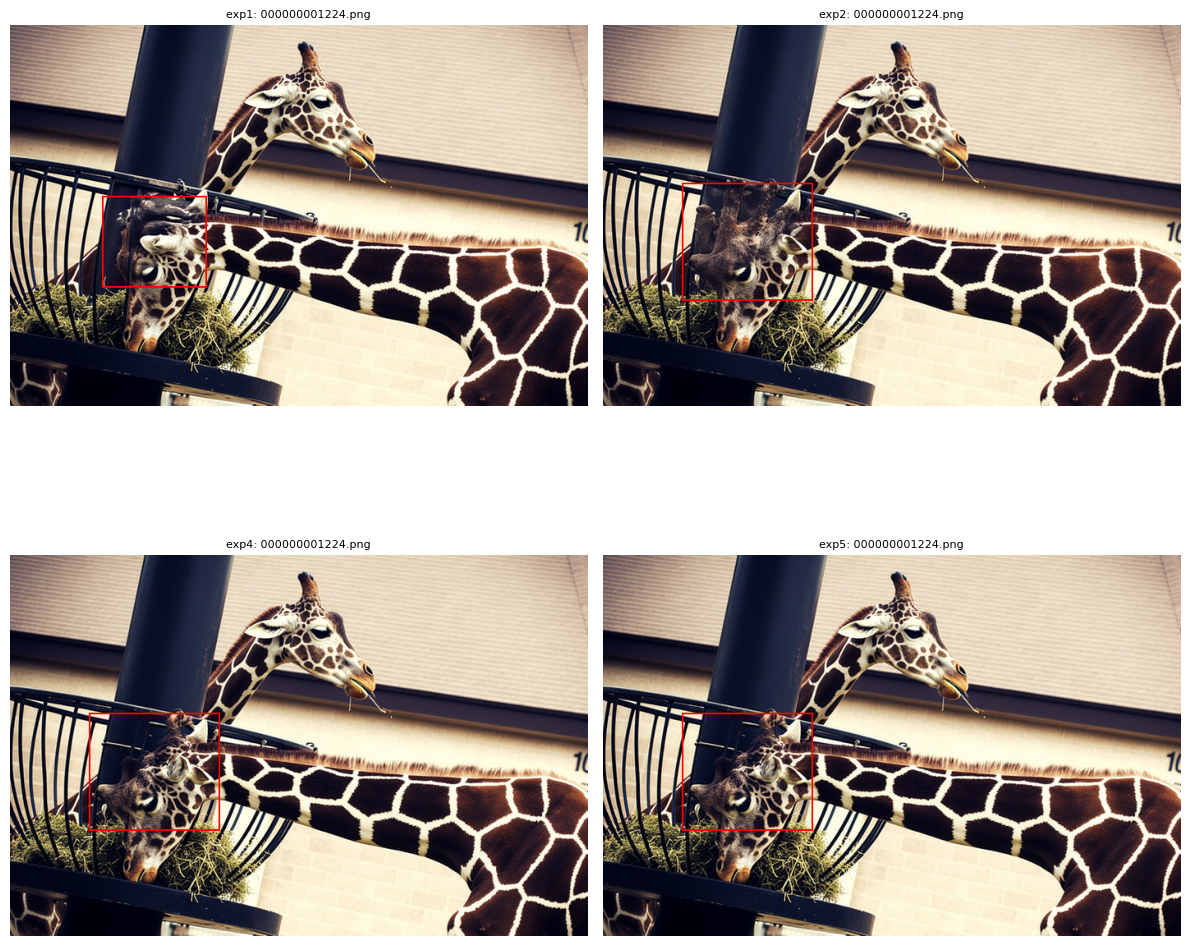

In [5]:
# In each cell execution, run this code to plot the next 2x2 grid
try:
    fig, axes = plt.subplots(2, 2, figsize=(12,12))
    axes = axes.flatten()
    for i in range(4):
        fname = next(image_iter)
        imgs = []
        for d in parent_dirs:
            img_path = os.path.join(d, fname)
            imgs.append(Image.open(img_path))
        for j, img in enumerate(imgs):
            ax = axes[j]
            ax.imshow(img)
            ax.set_title(f"{os.path.basename(parent_dirs[j])}: {fname}", fontsize=8)
            ax.axis('off')
        # Only plot the first 4 images (one per directory) in this cell
        break
    plt.tight_layout()
    plt.show()
except StopIteration:
    print("No more images to display.")
